In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import os
from scipy import stats

In [14]:
file_path_4A = '/Users/zkf/Desktop/test/figure/动态时间分层预测-生活方式-即时保存-两模型/汇总.csv'
file_path_4B = '/Users/zkf/Desktop/预上传github代码'
file_path_4C = '/Users/zkf/Desktop/预上传github代码/heart_shap_cache'
file_path_4D_1 = '/Users/zkf/Desktop/新项目/预处理后的原始数据/整个人群的患病数据包含协变量.csv'
file_path_4D_2 = '/Users/zkf/Desktop/新项目/预处理后的原始数据/蛋白质训练测试数据/all_train.csv'
file_path_4D_3 = '/Users/zkf/Desktop/新项目/预处理后的原始数据/蛋白质训练测试数据/all_test.csv'

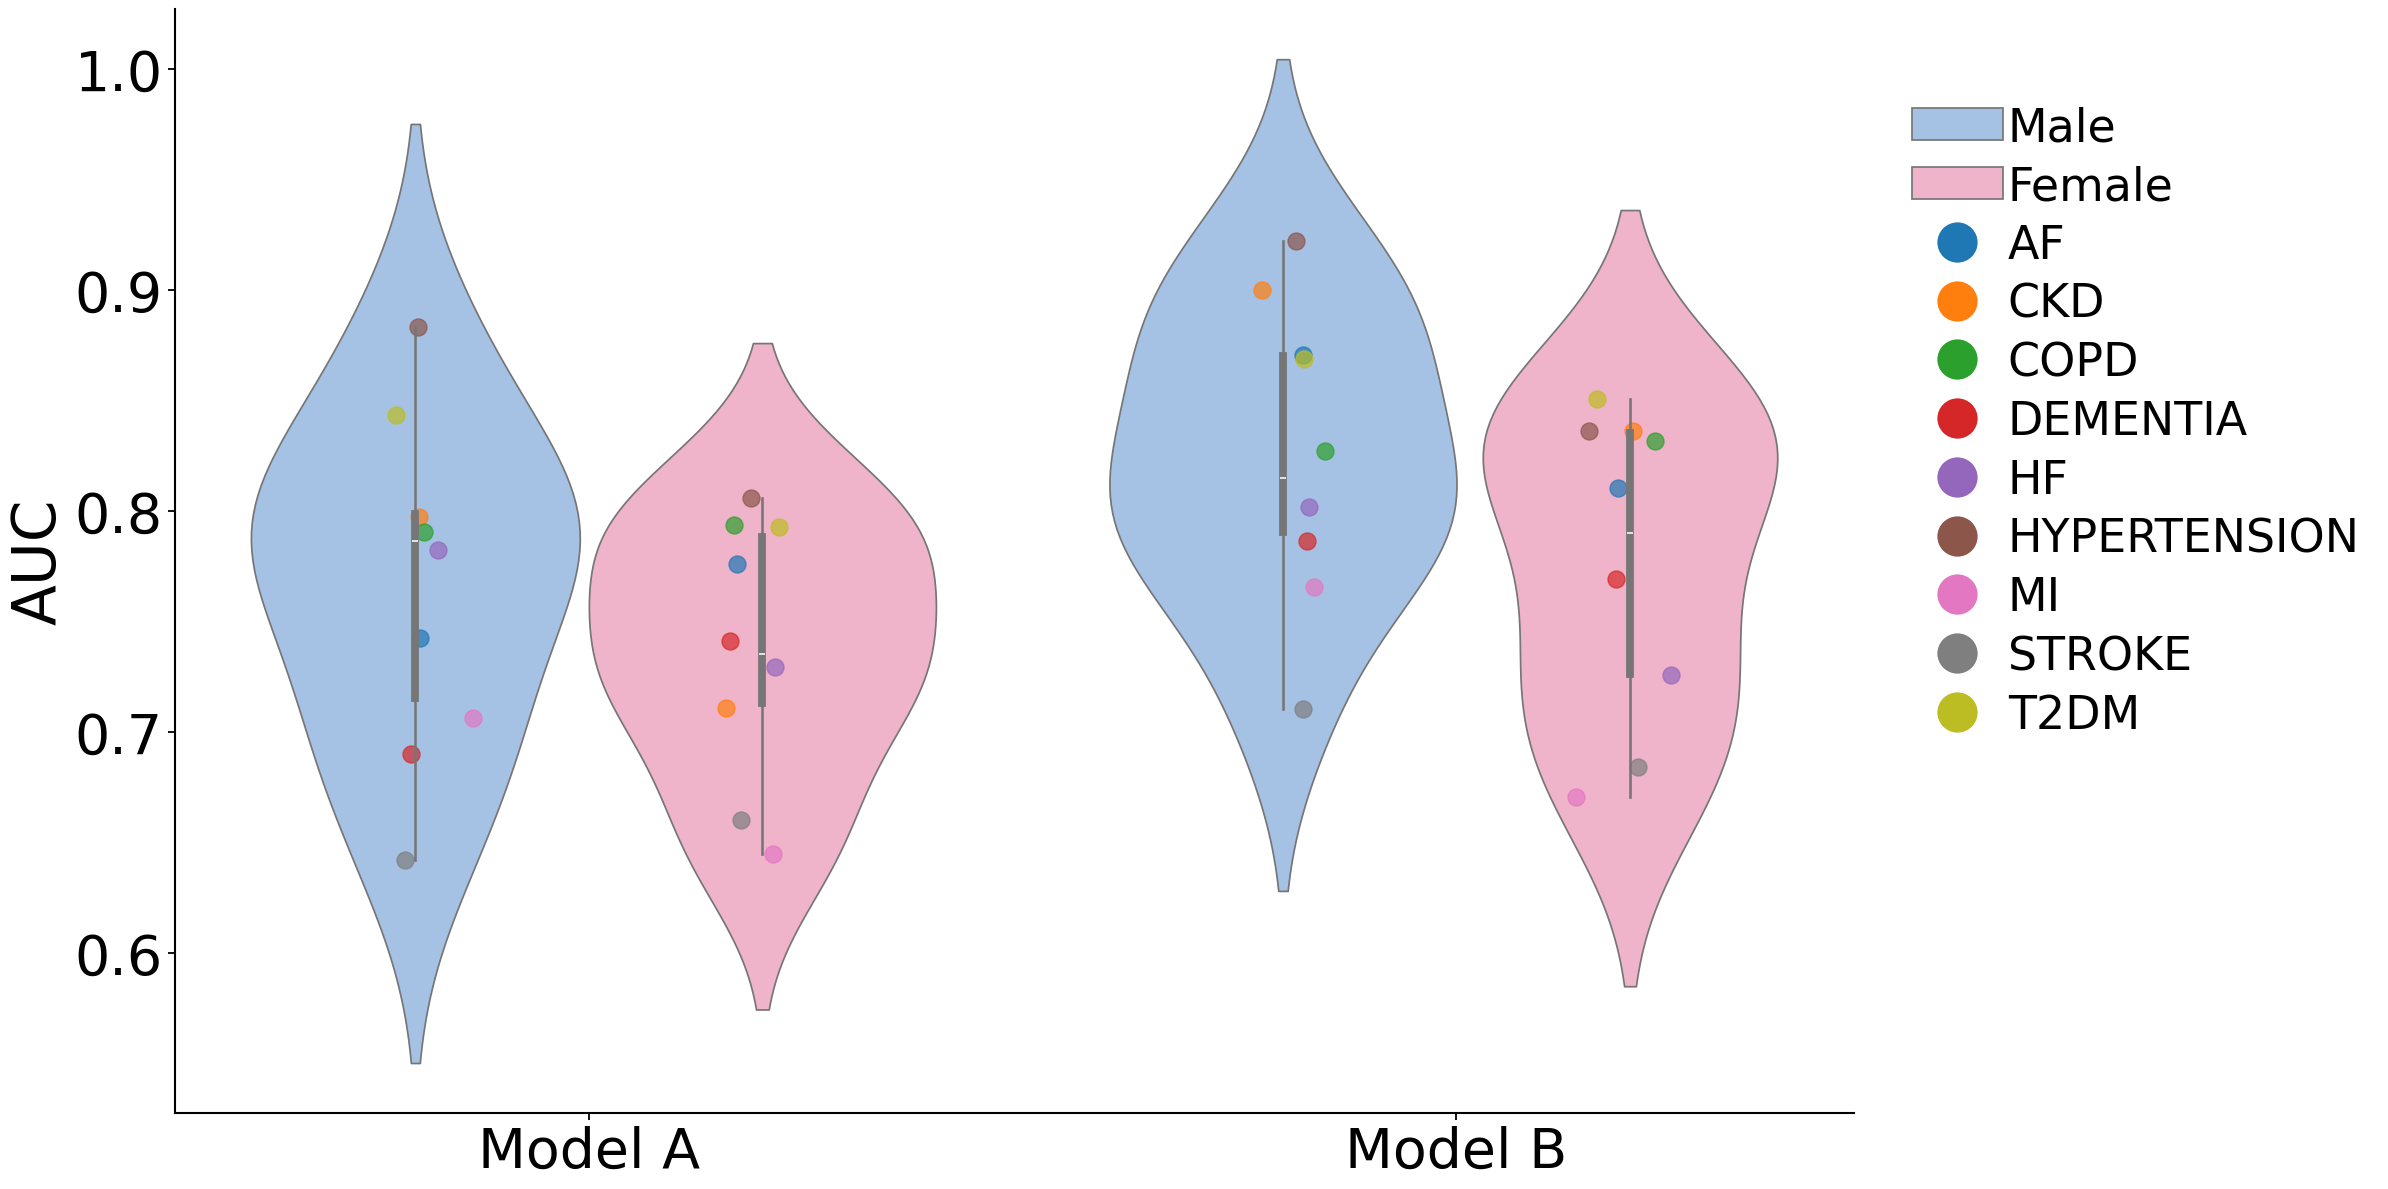

In [5]:
# Fig.4A


df = pd.read_csv(file_path_4A)

df_15Y = df[df['TimeWindow'] == '15Y'].copy()

df_15Y['Model'] = df_15Y['Model'].str.replace('_', ' ')

disease_colors = {
    'AF': '#1f77b4',
    'CKD': '#ff7f0e',
    'COPD': '#2ca02c',
    'DEMENTIA': '#d62728',
    'HF': '#9467bd',
    'HYPERTENSION': '#8c564b',
    'MI': '#e377c2',
    'STROKE': '#7f7f7f',
    'T2DM': '#bcbd22'
}

fig = plt.figure(figsize=(24, 12))



ax = plt.gca()

gender_palette = {'Male': '#9ac1f0', 'Female': '#faaac7'}
sns.violinplot(x="Model", y="AUC", hue="Sex", data=df_15Y, palette=gender_palette, split=False, inner="box")

handles = []
labels = []

for disease, color in disease_colors.items():
    disease_data = df_15Y[df_15Y['Disease'] == disease]
    if not disease_data.empty:
        for sex in ['Male', 'Female']:
            sex_data = disease_data[disease_data['Sex'] == sex]
            if not sex_data.empty:
                x_offset = 0.2 if sex == 'Female' else -0.2
                x_positions = [0, 1]
                for i, model in enumerate(['Model A', 'Model B']):
                    model_data = sex_data[sex_data['Model'] == model]
                    if not model_data.empty:
                        jitter = np.random.normal(0, 0.025, len(model_data))
                        x_positions_with_jitter = [x_positions[i] + x_offset + j for j in jitter]
                        plt.scatter(
                            x_positions_with_jitter,
                            model_data['AUC'],
                            color=color,
                            alpha=0.7,
                            s=150,
                            label=f'{disease} ({sex})'
                        )
        handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=30))
        labels.append(disease)

plt.xlabel("", fontsize=43)
plt.ylabel("AUC", fontsize=43)

violin_legend = ax.get_legend()
if violin_legend:
    gender_handles = violin_legend.legend_handles
    gender_labels = [t.get_text() for t in violin_legend.get_texts()]
    handles = gender_handles + handles
    labels = gender_labels + labels

plt.legend(handles=handles, labels=labels, fontsize=33, loc='upper left',
           bbox_to_anchor=(1.01, 0.95),
           handletextpad=0.1,
           frameon=False,
           labelspacing=0.3)

plt.tick_params(axis='both', which='major', width=1.3, length=5)
for axis in ['bottom', 'left']:
    ax.spines[axis].set_linewidth(1.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=40)

plt.tight_layout()
plt.show()

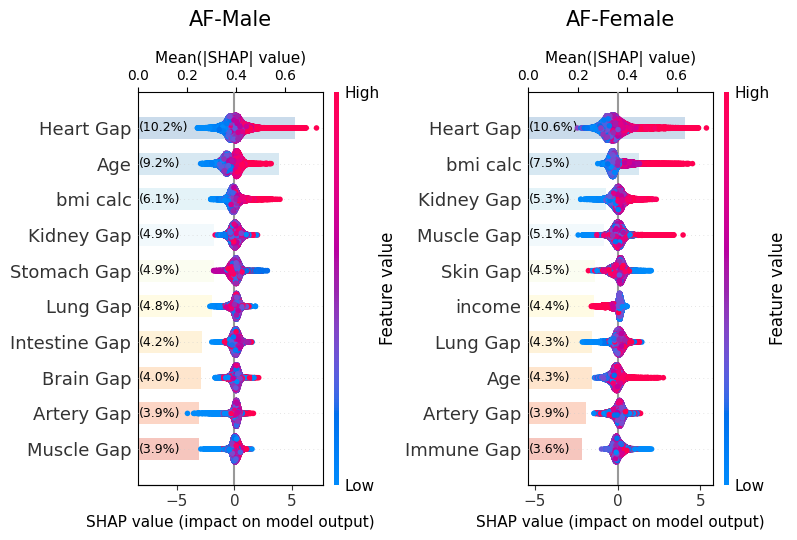

In [9]:
# Fig.4B
disease_name = 'AF'
TOP_N = 10

def plot_shap_subplot(ax, shap_values, X_data, feature_names, top_features, title):
    top_features = [f for f in top_features if f in feature_names]
    if not top_features:
        return
    feature_importance = np.abs(shap_values).mean(axis=0)
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': feature_importance
    }).sort_values('Importance', ascending=False)
    top_n = min(TOP_N, len(importance_df))
    top_features_sorted = importance_df.head(top_n)['Feature'].tolist()
    display_name_map = {'age_at_assessment': 'Age', 'beer_cider_intake': 'Beer/Cider'}
    top_features_display = []
    for f in top_features_sorted:
        display_name = display_name_map.get(f, f)
        display_name = display_name.replace('_Z_', ' ')
        display_name = display_name.replace('_', ' ')
        top_features_display.append(display_name)
    top_feature_indices = [list(feature_names).index(f) for f in top_features_sorted]
    shap_values_top = shap_values[:, top_feature_indices]
    feature_name_map = dict(zip(top_features_sorted, top_features_display))
    plt.sca(ax)
    explanation = shap.Explanation(
        values=shap_values_top,
        data=X_data[:, top_feature_indices],
        feature_names=top_features_display
    )
    try:
        shap.plots.beeswarm(explanation, max_display=top_n, show=False)
    except Exception:
        shap.summary_plot(shap_values_top, X_data[:, top_feature_indices], feature_names=top_features_display, max_display=top_n, show=False)
    ax_bee = ax
    for cbar in ax_bee.figure.axes:
        if isinstance(cbar, plt.Axes) and cbar.get_title() == 'Feature value':
            cbar.set_title('Feature value', pad=-15)
            break
    y_coords = ax_bee.get_yticks()
    y_labels = [tick.get_text() for tick in ax_bee.get_yticklabels()]
    valid_pairs = [(y, lab) for y, lab in zip(y_coords, y_labels) if str(lab).strip() != ""]
    if len(valid_pairs) == 0:
        return
    y_coords = np.array([p[0] for p in valid_pairs])
    y_labels = [p[1] for p in valid_pairs]
    importance_dict = dict(zip(importance_df['Feature'], importance_df['Importance']))
    total_importance = importance_df['Importance'].sum()
    display_importance = []
    display_pcts = []
    for label in y_labels:
        original_feature = None
        for feat, display in feature_name_map.items():
            if display == label:
                original_feature = feat
                break
        if original_feature and original_feature in importance_dict:
            imp = importance_dict[original_feature]
            pct = (imp / total_importance) * 100 if total_importance > 0 else 0
            display_importance.append(imp)
            display_pcts.append(pct)
        else:
            display_importance.append(0)
            display_pcts.append(0)
    ax_bar = ax_bee.twiny()
    cmap = plt.get_cmap("RdYlBu")
    colors = cmap(np.linspace(0.15, 0.85, len(y_coords)))
    bar_widths = np.array(display_importance, dtype=float)
    bar_pcts = np.array(display_pcts, dtype=float)
    ax_bar.barh(y=y_coords, width=bar_widths, height=0.62, color=colors, alpha=0.32, edgecolor='none')
    max_w = bar_widths.max() if len(bar_widths) > 0 else 1
    for y, p in zip(y_coords, bar_pcts):
        ax_bar.text(x=0, y=y, s=f"({p:.1f}%)", va='center', ha='left', fontsize=9)
    ax_bar.set_xlim(0, max_w * 1.18 if max_w > 0 else 1)
    ax_bar.set_xlabel("Mean(|SHAP| value)", fontsize=11)
    ax_bar.xaxis.set_label_position('top')
    ax_bar.xaxis.tick_top()
    ax_bar.grid(False)
    xmin, xmax = ax_bee.get_xlim()
    xrange_ = xmax - xmin
    ax_bee.set_xlim(xmin - xrange_ * 0.30, xmax)
    ax_bee.set_xlabel("SHAP value (impact on model output)", fontsize=11)
    ax_bee.set_ylabel("")
    ax_bee.set_title(title, fontsize=15, pad=18)
    ax_bee.tick_params(axis='y', pad=-15)
    ax_bar.set_zorder(0)
    ax_bee.set_zorder(1)
    ax_bee.patch.set_alpha(0)

def load_sex_cache(sex):
    X_arr = np.load(os.path.join(file_path_4B, f'{disease_name}_{sex}_X.npy'))
    shap_arr = np.load(os.path.join(file_path_4B, f'{disease_name}_{sex}_shap_vals.npy'))
    col_df = pd.read_csv(os.path.join(file_path_4B, f'{disease_name}_{sex}_cols.csv'))
    cols = col_df['colname'].tolist()
    top_df = pd.read_csv(os.path.join(file_path_4B, f'{disease_name}_{sex}_topfeat.csv'))
    top_feats = top_df['top_feature'].tolist()
    imp_df = pd.read_csv(os.path.join(file_path_4B, f'{disease_name}_{sex}_importance.csv'))
    return X_arr, shap_arr, cols, top_feats, imp_df

def draw_shap_figure():
    male_X, male_shap, male_cols, male_top, _ = load_sex_cache("Male")
    female_X, female_shap, female_cols, female_top, _ = load_sex_cache("Female")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(60, 12))
    
    plot_shap_subplot(ax1, male_shap, male_X, male_cols, male_top, f"{disease_name}-Male")
    plot_shap_subplot(ax2, female_shap, female_X, female_cols, female_top, f"{disease_name}-Female")
    plt.tight_layout()
    plt.show()

draw_shap_figure()

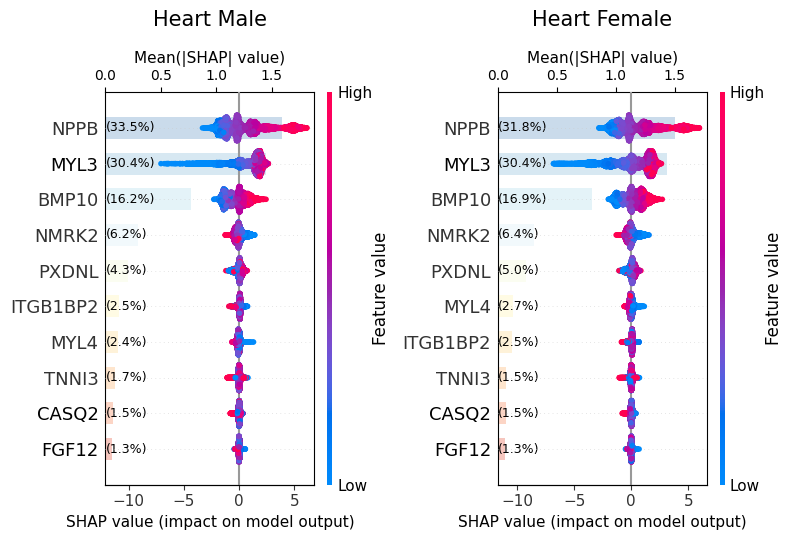

In [12]:
# Fig.4C





organ = 'Heart'
TOP_N = 20

def plot_shap_subplot(ax, shap_values, X_data, feature_names, top_features, title, cell_genes):
    top_feature_indices = [feature_names.index(f) for f in top_features]
    shap_values_top = shap_values[:, top_feature_indices]

    feature_importance = np.abs(shap_values_top).mean(axis=0)
    importance_df = pd.DataFrame({
        'Feature': top_features,
        'Importance': feature_importance
    }).sort_values('Importance', ascending=False)

    top_features_sorted = importance_df['Feature'].tolist()
    top_feature_indices_sorted = [feature_names.index(f) for f in top_features_sorted]
    shap_values_sorted = shap_values[:, top_feature_indices_sorted]
    X_sorted = X_data[:, top_feature_indices_sorted]

    bar_widths_full = importance_df['Importance'].values
    bar_pcts_full = bar_widths_full / bar_widths_full.sum() * 100

    plt.sca(ax)
    explanation = shap.Explanation(
        values=shap_values_sorted,
        data=X_sorted,
        feature_names=top_features_sorted
    )
    try:
        shap.plots.beeswarm(
            explanation,
            max_display=min(TOP_N, len(top_features_sorted)),
            show=False
        )
    except Exception:
        shap.summary_plot(
            shap_values_sorted,
            X_sorted,
            feature_names=top_features_sorted,
            max_display=min(TOP_N, len(top_features_sorted)),
            show=False
        )

    ax_bee = ax
    for cbar in ax_bee.figure.axes:
        if isinstance(cbar, plt.Axes) and cbar.get_title() == 'Feature value':
            cbar.set_title('Feature value', pad=-15)
            break

    y_coords = ax_bee.get_yticks()
    y_labels = [tick.get_text() for tick in ax_bee.get_yticklabels()]
    valid_pairs = [(y, lab) for y, lab in zip(y_coords, y_labels) if str(lab).strip() != ""]
    if len(valid_pairs) == 0:
        raise ValueError("beeswarm 图未获取到有效的 y 轴标签")
    y_coords = np.array([p[0] for p in valid_pairs])
    y_labels = [p[1] for p in valid_pairs]

    imp_map = dict(zip(importance_df['Feature'], importance_df['Importance']))
    pct_map = dict(zip(importance_df['Feature'], bar_pcts_full))
    bar_widths = np.array([imp_map.get(f, 0) for f in y_labels], dtype=float)
    bar_pcts = np.array([pct_map.get(f, 0) for f in y_labels], dtype=float)

    ax_bar = ax_bee.twiny()
    cmap = plt.get_cmap("RdYlBu")
    colors = cmap(np.linspace(0.15, 0.85, len(y_coords)))
    ax_bar.barh(y=y_coords, width=bar_widths, height=0.62, color=colors, alpha=0.32, edgecolor='none')

    max_w = bar_widths.max() if len(bar_widths) > 0 else 1
    for y, p in zip(y_coords, bar_pcts):
        ax_bar.text(x=0, y=y, s=f"({p:.1f}%)", va='center', ha='left', fontsize=9)

    ax_bar.set_xlim(0, max_w * 1.18 if max_w > 0 else 1)
    ax_bar.set_xlabel("Mean(|SHAP| value)", fontsize=11)
    ax_bar.xaxis.set_label_position('top')
    ax_bar.xaxis.tick_top()
    ax_bar.grid(False)

    ax_bee.set_xlabel("SHAP value (impact on model output)", fontsize=11)
    xmin, xmax = ax_bee.get_xlim()
    xrange_ = xmax - xmin
    ax_bee.set_xlim(xmin - xrange_ * 0.30, xmax)
    ax_bee.set_ylabel("")
    ax_bee.set_title(title, fontsize=15, pad=18)
    ax_bee.tick_params(axis='y', pad=-15)

    y_ticklabels = ax_bee.get_yticklabels()
    for label in y_ticklabels:
        feature_name = label.get_text().strip()
        if feature_name and feature_name not in cell_genes:
            label.set_color('black')

    ax_bar.set_zorder(0)
    ax_bee.set_zorder(1)
    ax_bee.patch.set_alpha(0)
    return importance_df

def load_all_cache():
    male_X = np.load(os.path.join(file_path_4C, "male_X.npy"))
    female_X = np.load(os.path.join(file_path_4C, "female_X.npy"))
    male_shap = np.load(os.path.join(file_path_4C, "male_shap_vals.npy"))
    female_shap = np.load(os.path.join(file_path_4C, "female_shap_vals.npy"))
    feat_df = pd.read_csv(os.path.join(file_path_4C, "feature_names.csv"))
    feature_names = feat_df["colname"].tolist()
    top_df = pd.read_csv(os.path.join(file_path_4C, "top_features.csv"))
    top_features = top_df["top_feature"].tolist()
    gene_df = pd.read_csv(os.path.join(file_path_4C, "cell_gene_list.csv"))
    cell_genes = set(gene_df["Gene"].tolist())
    return male_X, female_X, male_shap, female_shap, feature_names, top_features, cell_genes

def draw_shap_figure():
    male_X, female_X, male_shap, female_shap, feature_names, top_features, cell_genes = load_all_cache()
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(60, 12))

    plot_shap_subplot(ax1, male_shap, male_X, feature_names, top_features, f"{organ} Male", cell_genes)
    plot_shap_subplot(ax2, female_shap, female_X, feature_names, top_features, f"{organ} Female", cell_genes)
    plt.tight_layout()
    plt.show()


draw_shap_figure()

In [17]:
# Fig.4D


plt.rcParams['font.family'] = ['Times New Roman']

palette = ['#0073C2FF', '#EFC000FF', '#868686FF']

df_disease = pd.read_csv(file_path_4D_1)

df_prot = pd.concat([
    pd.read_csv(file_path_4D_2),
    pd.read_csv(file_path_4D_3)
], axis=0)

df = pd.merge(df_disease, df_prot, on='eid', how='inner')

df['assess_date'] = pd.to_datetime(df['assess_date'], errors='coerce')
df['date_af'] = pd.to_datetime(df['date_af'], errors='coerce')

df['years_to_event'] = (df['date_af'] - df['assess_date']).dt.days / 365.25

T = 15
is_case = (df['years_to_event'] > 0) & (df['years_to_event'] <= T)
is_control = (df['years_to_event'].isna()) | (df['years_to_event'] > T)

df['label'] = np.nan
df.loc[is_case, 'label'] = 1
df.loc[is_control, 'label'] = 0
df = df.dropna(subset=['label']).copy()
df['label'] = df['label'].astype(int)

proteins = ['nppb', 'myl3']
protein_names = {'nppb': 'NPPB', 'myl3': 'MYL3'}

def add_significance_line(ax, x1, x2, y, h, text, lw=1.5, fs=33):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, c='k')
    ax.text((x1 + x2) * 0.5, y + h, text,
            ha='center', va='bottom', color='k', fontsize=fs)

sns.set_style("white")

fig, axes = plt.subplots(1, 2, figsize=(24, 12), dpi=600, facecolor="w")



for i, protein in enumerate(proteins):
    ax = axes[i]
    display_name = protein_names.get(protein, protein.upper())

    if protein not in df.columns:
        ax.set_title(f'{display_name} - Not Found', fontsize=14)
        ax.axis('off')
        continue

    plot_df = df[['label', protein]].dropna().copy()

    plot_df['group'] = plot_df['label'].map({0: 'Non-AF', 1: 'AF'})

    sns.boxplot(
        x='group',
        y=protein,
        data=plot_df,
        order=['Non-AF', 'AF'],
        palette=[palette[0], palette[1]],
        showfliers=False,
        width=0.55,
        ax=ax,
        boxprops=dict(edgecolor='k', linewidth=1.5),
        whiskerprops=dict(color='k', linewidth=1.5),
        capprops=dict(color='k', linewidth=1.5),
        medianprops=dict(color='k', linewidth=1.5)
    )

    healthy = plot_df.loc[plot_df['group'] == 'Non-AF', protein].dropna()
    unhealthy = plot_df.loc[plot_df['group'] == 'AF', protein].dropna()

    if len(healthy) > 0 and len(unhealthy) > 0:
        t_stat, p_value = stats.ttest_ind(healthy, unhealthy, equal_var=False)

        if p_value < 0.0001:
            p_text = "p < 0.0001"
        else:
            p_text = f"p = {p_value:.4g}"

        y_max = max(plot_df[protein].max(), np.percentile(plot_df[protein], 99))
        y_min = plot_df[protein].min()
        y_range = y_max - y_min

        if y_range == 0:
            y_range = 1

        y = y_max + y_range * 0.08
        h = y_range * 0.05

        add_significance_line(
            ax=ax,
            x1=0,
            x2=1,
            y=y,
            h=h,
            text=p_text,
            lw=1.2,
            fs=37
        )

        ax.set_ylim(y_min, y + h + y_range * 0.12)

    ax.set_title(display_name, fontsize=40)
    ax.set_xlabel('AF Status', fontsize=43)
    ax.set_ylabel(display_name, fontsize=43)

    ax.set_xticklabels(['Non-AF', 'AF'], fontsize=40)

    ax.tick_params(
        axis='both',
        which='major',
        width=1.3,
        length=5,
        labelsize=40
    )

    for axis in ['bottom', 'left']:
        ax.spines[axis].set_linewidth(1.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.grid(axis='y', ls='--', c='gray', alpha=0.7)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

/var/folders/ll/3l49qks5171c56bp6lrdydjc0000gn/T/ipykernel_15699/4196042617.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/ll/3l49qks5171c56bp6lrdydjc0000gn/T/ipykernel_15699/4196042617.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Non-AF', 'AF'], fontsize=40)
/var/folders/ll/3l49qks5171c56bp6lrdydjc0000gn/T/ipykernel_15699/4196042617.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/ll/3l49qks5171c56bp6lrdydjc0000gn/T/ipykernel_15699/4196042617.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after